<a href="https://colab.research.google.com/github/SejalSNikumbh/App_Tracking/blob/main/App_Tracking_jpynp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Helper function to generate random timestamps
def random_date(start, end):
    return start + timedelta(
        seconds=random.randint(0, int((end - start).total_seconds()))
    )

# Define the range for the ride events
start_date = datetime(2024, 9, 1)
end_date = datetime(2024, 9, 26)

# Example data generation
data = {
    "User_ID": [f"U{str(i).zfill(4)}" for i in range(1, 101)],  # 100 Users
    "Session_ID": [f"S{random.randint(10000, 99999)}" for _ in range(100)],  # Random Session IDs
    "Device_ID": [f"D{random.randint(1000, 9999)}" for _ in range(100)],  # Random Device IDs
    "App_Version": [random.choice(["1.0", "1.1", "1.2", "2.0"]) for _ in range(100)],  # App versions
    "Event_Name": [random.choice(["Booking", "Cancellation", "Ride Start", "Ride End", "Payment"]) for _ in range(100)],
    "Event_Time": [random_date(start_date, end_date) for _ in range(100)],  # Random dates within a period
    "Pickup_Location": [random.choice(["New York", "Los Angeles", "Mumbai", "London", "Berlin"]) for _ in range(100)],
    "Dropoff_Location": [random.choice(["San Francisco", "Chicago", "Delhi", "Paris", "Amsterdam"]) for _ in range(100)],
    "Ride_Distance_km": [round(random.uniform(5.0, 50.0), 2) for _ in range(100)],  # Random ride distances
    "Driver_Rating": [round(random.uniform(1.0, 5.0), 1) for _ in range(100)],  # Random driver ratings between 1 and 5
    "Fare_Amount": [round(random.uniform(10.0, 100.0), 2) for _ in range(100)],  # Random fare amounts
}

# Creating DataFrame
cab_ride_df = pd.DataFrame(data)



In [ ]:

cab_ride_df.to_csv("cab_ride_data.csv", index=False)


In [ ]:
# Display first few rows of the dataset
cab_ride_df.head(6)

,User_ID,Session_ID,Device_ID,App_Version,Event_Name,Event_Time,Pickup_Location,Dropoff_Location,Ride_Distance_km,Driver_Rating,Fare_Amount
0,U0001,S68655,D4662,1.2,Ride Start,2024-09-15 15:15:21,2,3,37.03,2.1,38.95
1,U0002,S17908,D3356,1.0,Ride End,2024-09-09 04:27:21,2,2,5.95,1.9,88.40
2,U0003,S37373,D5839,1.2,Ride End,2024-09-03 09:25:36,0,0,40.56,4.5,89.04
3,U0004,S52304,D9387,2.0,Cancellation,2024-09-06 11:41:43,0,3,42.09,1.2,14.07
4,U0005,S91535,D7370,1.2,Ride Start,2024-09-19 23:03:49,3,3,5.29,3.3,56.03
5,U0006,S22781,D5375,1.0,Ride End,2024-09-11 21:40:00,3,3,31.18,3.3,62.73


In [ ]:
cab_ride_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           100 non-null    object        
 1   Session_ID        100 non-null    object        
 2   Device_ID         100 non-null    object        
 3   App_Version       100 non-null    object        
 4   Event_Name        100 non-null    object        
 5   Event_Time        100 non-null    datetime64[ns]
 6   Pickup_Location   100 non-null    int64         
 7   Dropoff_Location  100 non-null    int64         
 8   Ride_Distance_km  100 non-null    float64       
 9   Driver_Rating     100 non-null    float64       
 10  Fare_Amount       100 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 8.7+ KB


In [ ]:
cab_ride_df.describe()

,Event_Time,Pickup_Location,Dropoff_Location,Ride_Distance_km,Driver_Rating,Fare_Amount
count,100,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2024-09-11 20:07:48.540000256,2.000000,2.050000,25.759500,3.124000,55.601800
min,2024-09-01 01:36:45,0.000000,0.000000,5.290000,1.100000,10.130000
25%,2024-09-07 04:59:53.249999872,1.000000,1.000000,15.412500,2.100000,31.410000
50%,2024-09-09 17:46:49,2.000000,2.000000,24.070000,3.100000,57.100000
75%,2024-09-17 05:57:57,3.000000,3.000000,35.027500,4.200000,80.530000
max,2024-09-25 16:50:24,4.000000,4.000000,49.810000,4.900000,99.510000
std,NaN,1.414214,1.416889,12.769167,1.142487,27.728556


<ipython-input-67-d8b8cb3bbb92>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




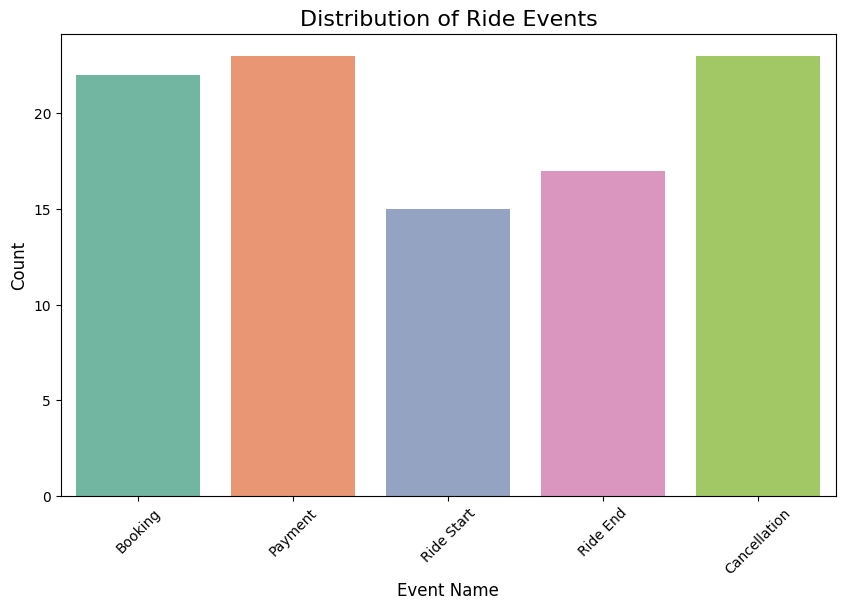

In [ ]:
# Distribution of Events
plt.figure(figsize=(10, 6))
sns.countplot(x='Event_Name', data=cab_ride_df, palette="Set2")
plt.title("Distribution of Ride Events", fontsize=16)
plt.xlabel("Event Name", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()

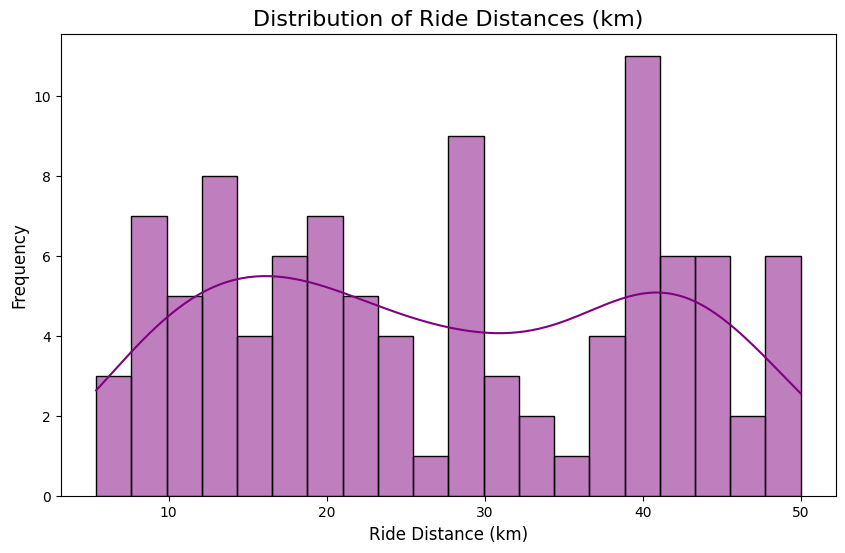

In [ ]:
#  Distribution of Ride Distances
plt.figure(figsize=(10, 6))
sns.histplot(cab_ride_df['Ride_Distance_km'], bins=20, kde=True, color="purple")
plt.title("Distribution of Ride Distances (km)", fontsize=16)
plt.xlabel("Ride Distance (km)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

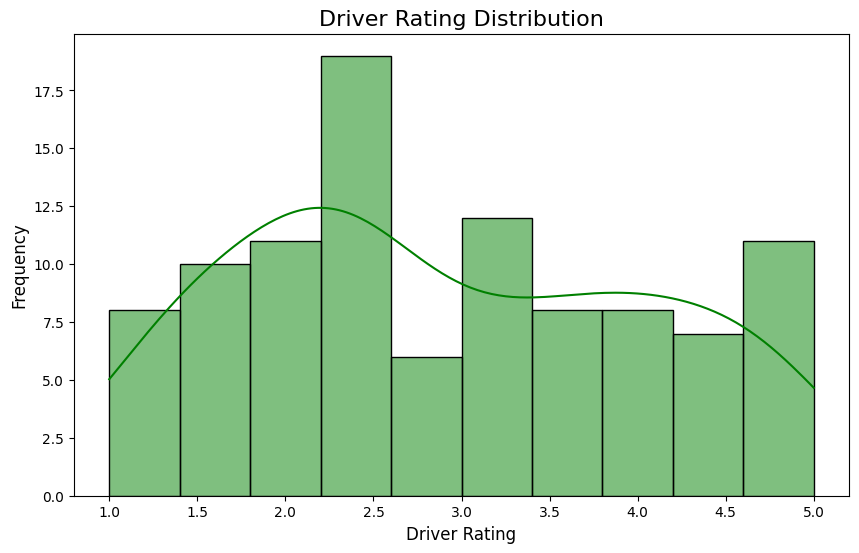

In [ ]:
# Driver Rating Distribution
plt.figure(figsize=(10, 6))
sns.histplot(cab_ride_df['Driver_Rating'], bins=10, kde=True, color="green")
plt.title("Driver Rating Distribution", fontsize=16)
plt.xlabel("Driver Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

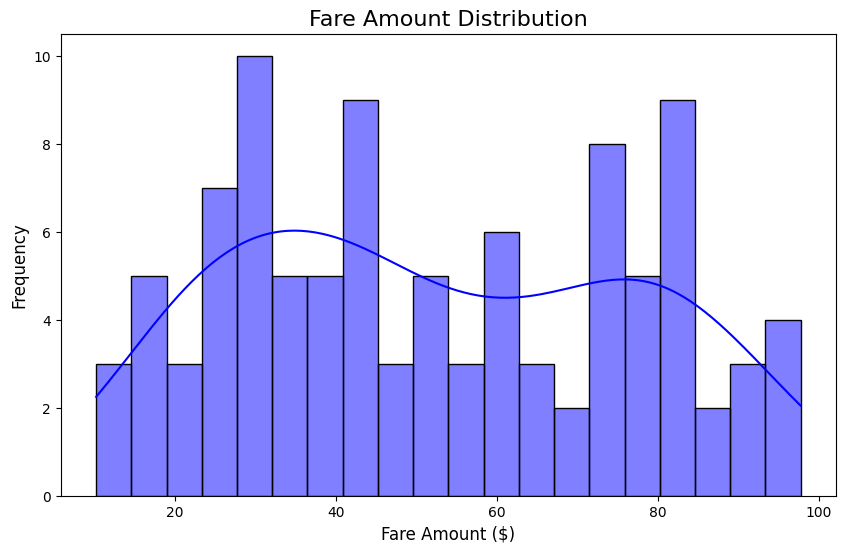

In [ ]:
# Fare Amount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(cab_ride_df['Fare_Amount'], bins=20, kde=True, color="blue")
plt.title("Fare Amount Distribution", fontsize=16)
plt.xlabel("Fare Amount ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()


<ipython-input-73-27f8ea0d4152>:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




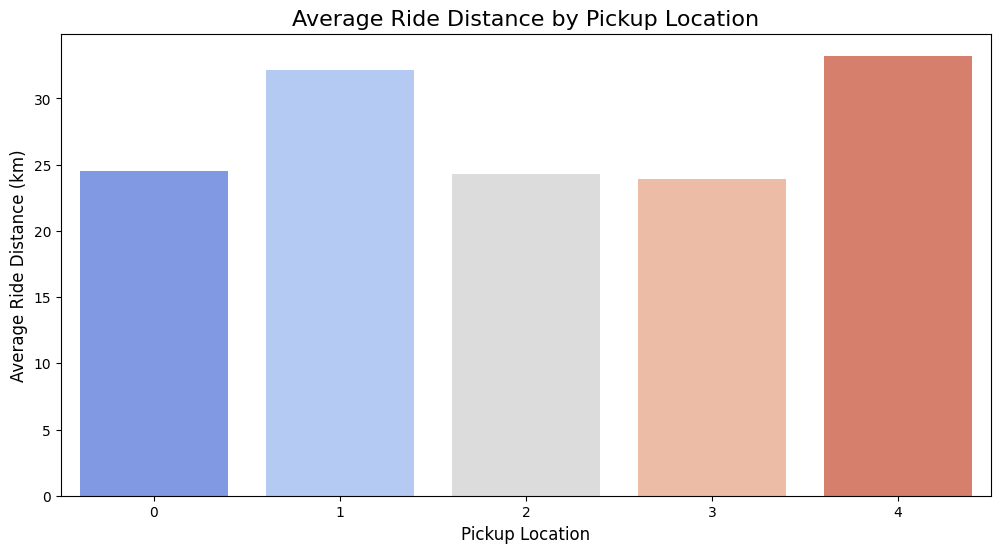

<ipython-input-73-27f8ea0d4152>:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




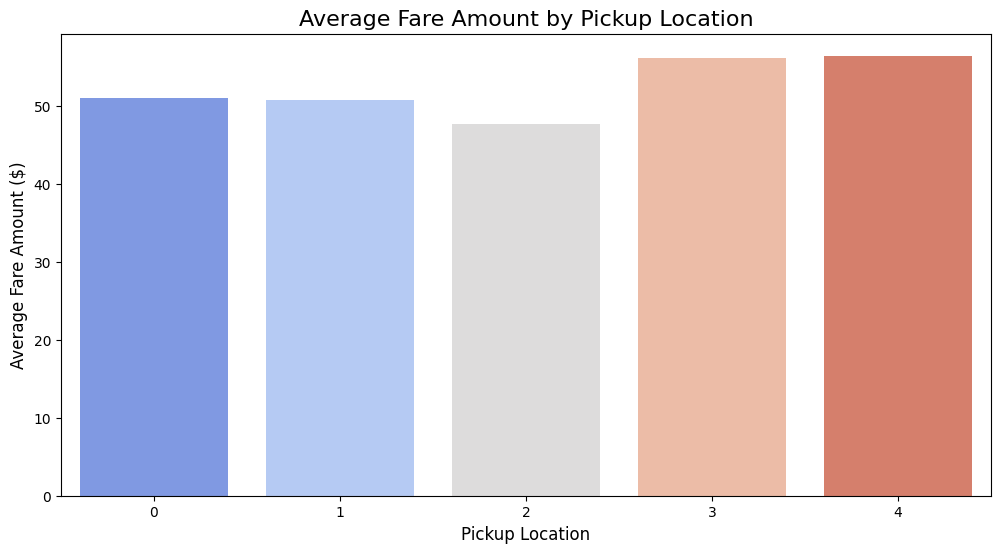

In [ ]:
#  Average Ride Distance and Fare by Pickup Location
avg_distance_fare = cab_ride_df.groupby('Pickup_Location').agg({
    'Ride_Distance_km': 'mean',
    'Fare_Amount': 'mean'
}).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Pickup_Location', y='Ride_Distance_km', data=avg_distance_fare, palette="coolwarm")
plt.title("Average Ride Distance by Pickup Location", fontsize=16)
plt.xlabel("Pickup Location", fontsize=12)
plt.ylabel("Average Ride Distance (km)", fontsize=12)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Pickup_Location', y='Fare_Amount', data=avg_distance_fare, palette="coolwarm")
plt.title("Average Fare Amount by Pickup Location", fontsize=16)
plt.xlabel("Pickup Location", fontsize=12)
plt.ylabel("Average Fare Amount ($)", fontsize=12)
plt.show()

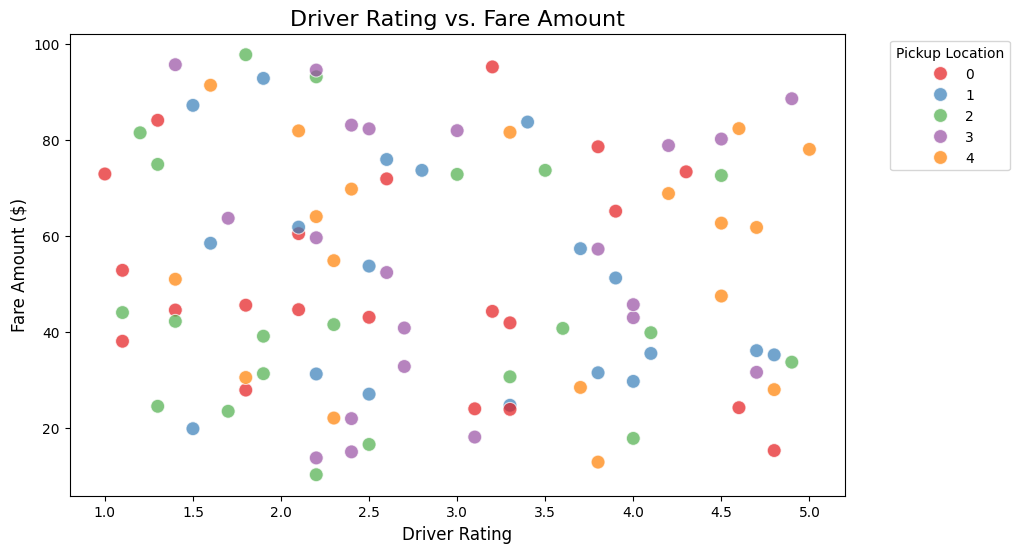

In [ ]:
# Driver Rating vs. Fare Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Driver_Rating', y='Fare_Amount', data=cab_ride_df, hue='Pickup_Location', palette="Set1", s=100, alpha=0.7)
plt.title("Driver Rating vs. Fare Amount", fontsize=16)
plt.xlabel("Driver Rating", fontsize=12)
plt.ylabel("Fare Amount ($)", fontsize=12)
plt.legend(title="Pickup Location", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

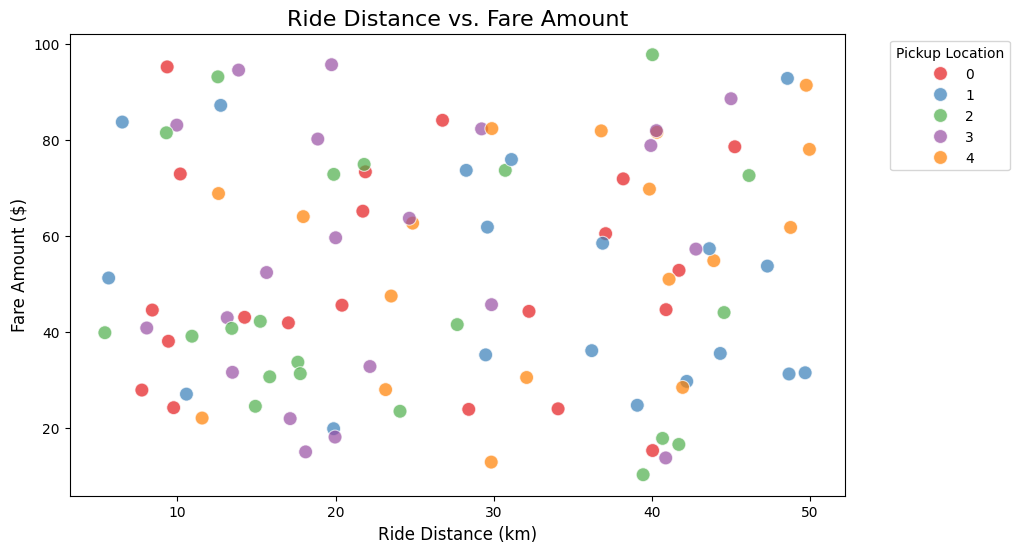

In [ ]:
#  Ride Distance vs. Fare Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ride_Distance_km', y='Fare_Amount', data=cab_ride_df, hue='Pickup_Location', palette="Set1", s=100, alpha=0.7)
plt.title("Ride Distance vs. Fare Amount", fontsize=16)
plt.xlabel("Ride Distance (km)", fontsize=12)
plt.ylabel("Fare Amount ($)", fontsize=12)
plt.legend(title="Pickup Location", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
#  only the pickup and dropoff locations
pickup_dropoff_df = cab_ride_df[['Pickup_Location', 'Dropoff_Location']]

# Display the new DataFrame
print(pickup_dropoff_df)


    Pickup_Location  Dropoff_Location
0                 2                 3
1                 2                 2
2                 0                 0
3                 0                 3
4                 3                 3
..              ...               ...
95                4                 1
96                0                 3
97                1                 0
98                0                 1
99                0                 3

[100 rows x 2 columns]


In [ ]:
cab_ride_df = cab_ride_df.dtypes

In [ ]:
cab_ride_df

,0
User_ID,object
Session_ID,object
Device_ID,object
App_Version,object
Event_Name,object
Event_Time,datetime64[ns]
Pickup_Location,int64
Dropoff_Location,int64
Ride_Distance_km,float64
Driver_Rating,float64


In [ ]:
print(cab_ride_df.head())

User_ID        object
Session_ID     object
Device_ID      object
App_Version    object
Event_Name     object
dtype: object


In [ ]:
import plotly.express as px
# Count the total number of bookings, payments, and cancellations
booking_count = cab_ride_df[cab_ride_df['Event_Name'] == 'Booking'].shape[0]
payment_count = cab_ride_df[cab_ride_df['Event_Name'] == 'Payment'].shape[0]
cancellation_count = cab_ride_df[cab_ride_df['Event_Name'] == 'Cancellation'].shape[0]

#prepare for pie chart
event_labels = ['Booking', 'Payment', 'Cancellation']
event_counts = [booking_count, payment_count, cancellation_count]

#Create a pie chart
fig = px.pie(
    values=event_counts,
    names=event_labels,
    title='Total Counts of Ride Events',
    color_discrete_sequence=px.colors.sequential.RdBu  # Color sequence
)

fig.show()

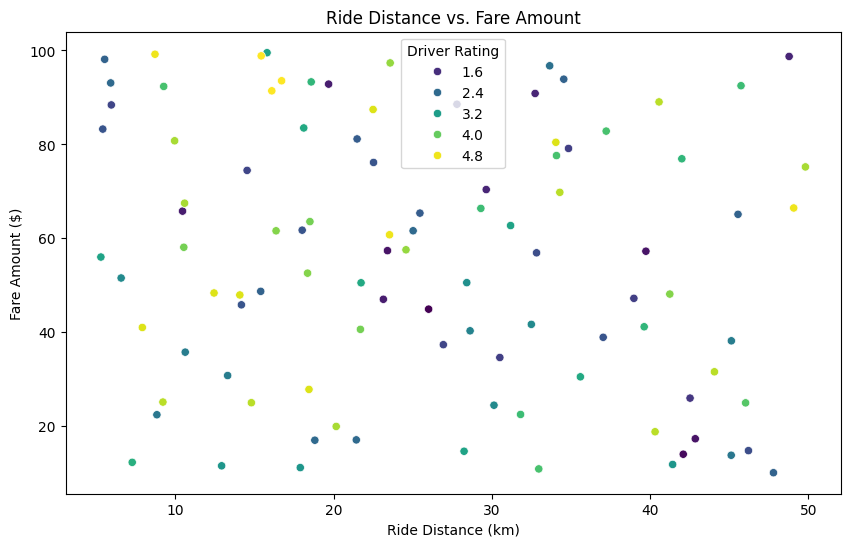

In [ ]:
# Scatter plot of Ride Distance vs. Fare Amount
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ride_Distance_km', y='Fare_Amount', data=cab_ride_df, hue='Driver_Rating', palette='viridis')
plt.title('Ride Distance vs. Fare Amount')
plt.xlabel('Ride Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.legend(title='Driver Rating')
plt.show()


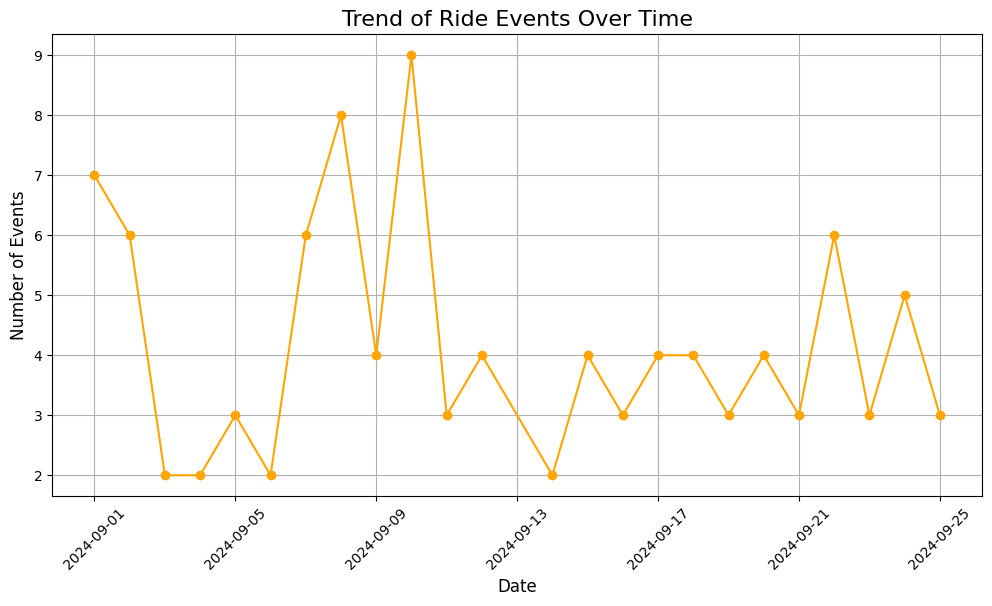

In [ ]:
# Trend of Events Over Time
plt.figure(figsize=(12, 6))
# Convert 'Event_Time' to datetime if not already
cab_ride_df['Event_Time'] = pd.to_datetime(cab_ride_df['Event_Time'])
event_trend = cab_ride_df.groupby(cab_ride_df['Event_Time'].dt.date)['Event_Name'].count()
event_trend.plot(kind='line', marker='o', color='orange')
plt.title("Trend of Ride Events Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Events", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

<ipython-input-77-e14e266b1413>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




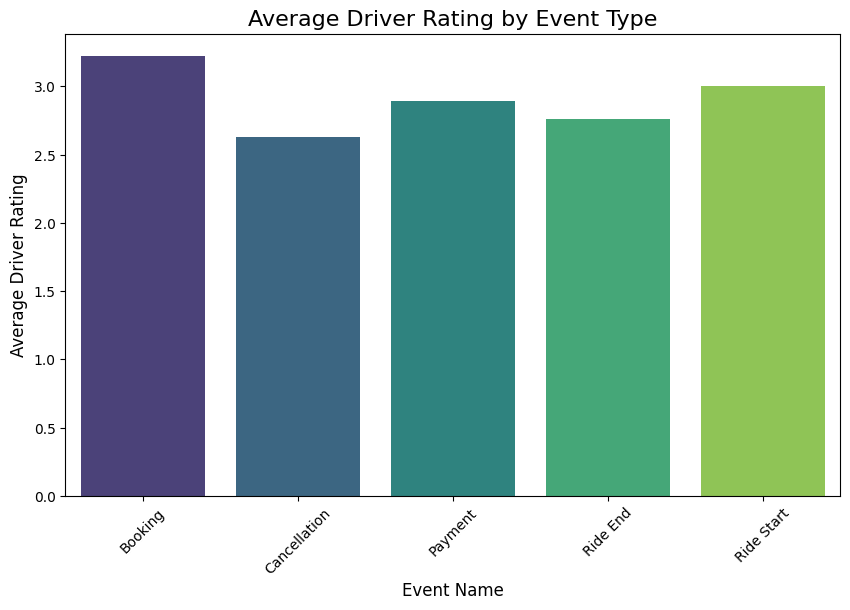

In [ ]:
# Average Driver Rating by Event Type
plt.figure(figsize=(10, 6))
avg_rating_by_event = cab_ride_df.groupby('Event_Name')['Driver_Rating'].mean().reset_index()
sns.barplot(x='Event_Name', y='Driver_Rating', data=avg_rating_by_event, palette="viridis")
plt.title("Average Driver Rating by Event Type", fontsize=16)
plt.xlabel("Event Name", fontsize=12)
plt.ylabel("Average Driver Rating", fontsize=12)
plt.xticks(rotation=45)
plt.show()


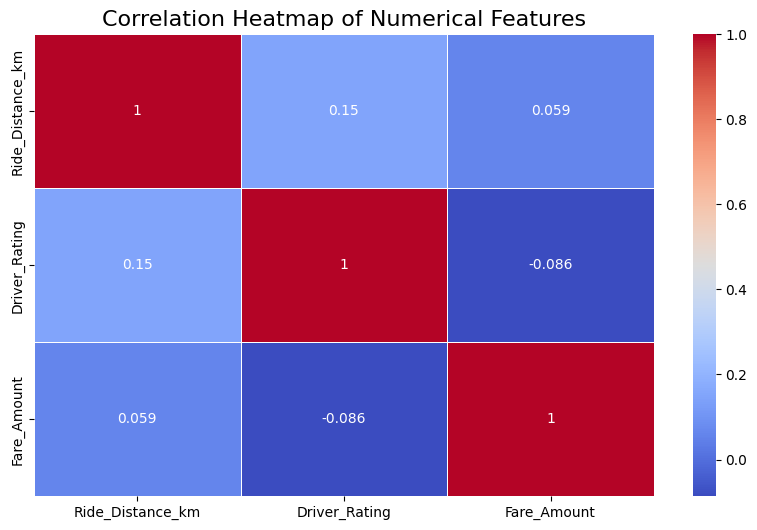

In [ ]:
#  Correlation Heatmap for Numerical Features
plt.figure(figsize=(10, 6))
correlation_matrix = cab_ride_df[['Ride_Distance_km', 'Driver_Rating', 'Fare_Amount']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()


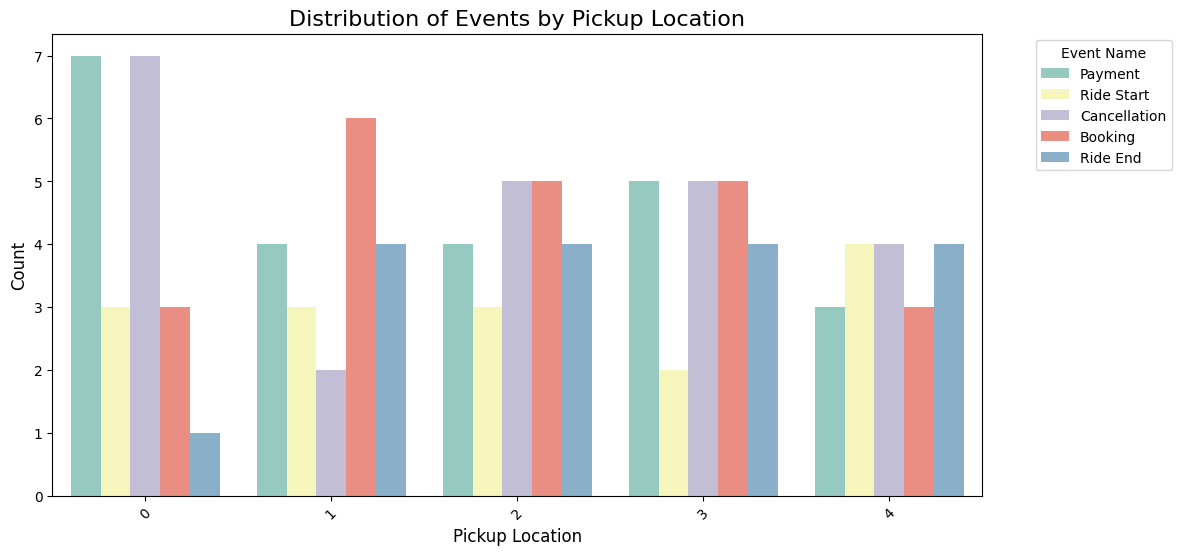

In [ ]:
#  Event Distribution by Pickup Location
plt.figure(figsize=(12, 6))
sns.countplot(x='Pickup_Location', hue='Event_Name', data=cab_ride_df, palette="Set3")
plt.title("Distribution of Events by Pickup Location", fontsize=16)
plt.xlabel("Pickup Location", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Event Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

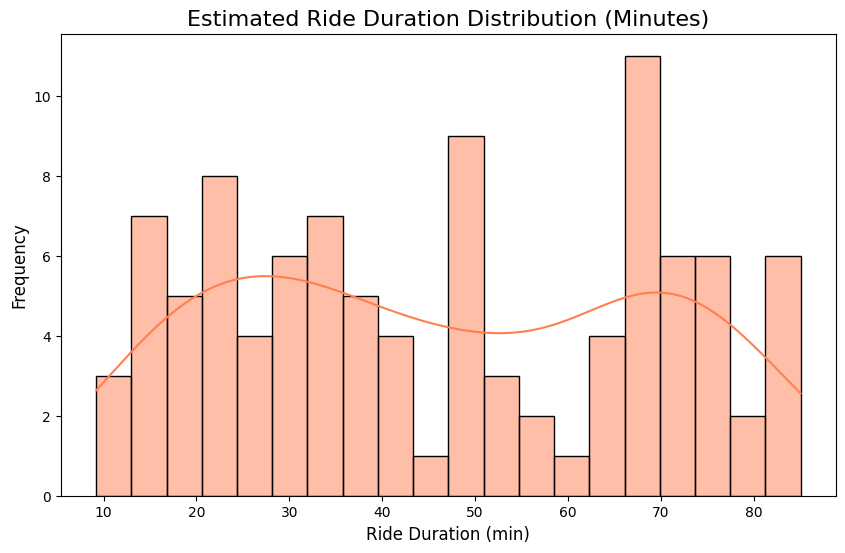

In [ ]:
#  Ride Duration Estimation
# Assuming ride distance is proportional to time (for this example)
cab_ride_df['Estimated_Ride_Duration_min'] = cab_ride_df['Ride_Distance_km'] * random.uniform(1.5, 2.5)

# Distribution of Estimated Ride Duration
plt.figure(figsize=(10, 6))
sns.histplot(cab_ride_df['Estimated_Ride_Duration_min'], bins=20, kde=True, color="coral")
plt.title("Estimated Ride Duration Distribution (Minutes)", fontsize=16)
plt.xlabel("Ride Duration (min)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()


<ipython-input-82-ec702efdee83>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




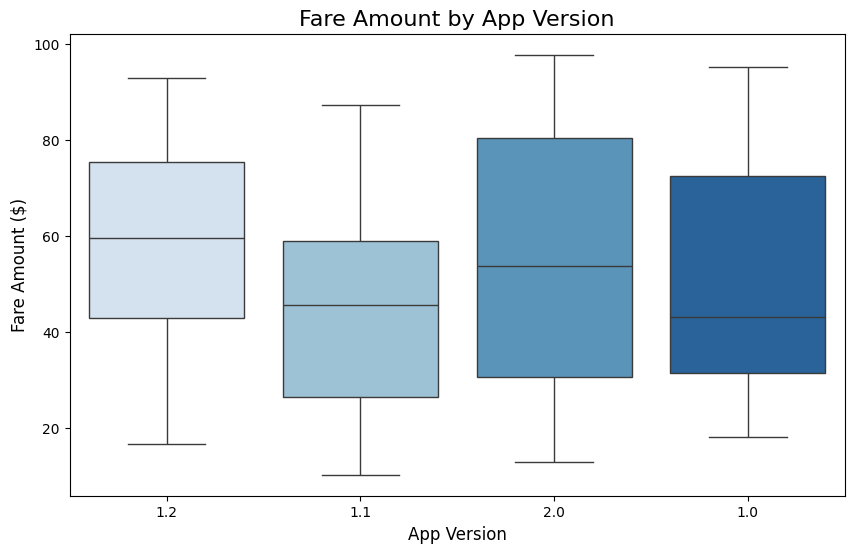

In [ ]:
#  Fare Amount by App Version
plt.figure(figsize=(10, 6))
sns.boxplot(x='App_Version', y='Fare_Amount', data=cab_ride_df, palette="Blues")
plt.title("Fare Amount by App Version", fontsize=16)
plt.xlabel("App Version", fontsize=12)
plt.ylabel("Fare Amount ($)", fontsize=12)
plt.show()


<ipython-input-83-6d24db899bfb>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




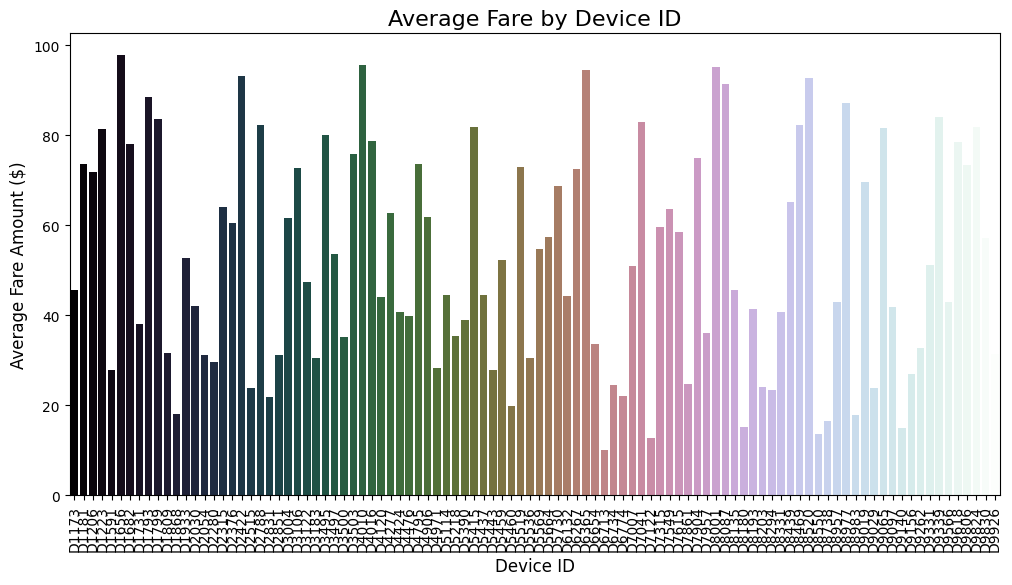

In [ ]:
# Average Fare by Device ID
avg_fare_by_device = cab_ride_df.groupby('Device_ID')['Fare_Amount'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Device_ID', y='Fare_Amount', data=avg_fare_by_device, palette="cubehelix")
plt.title("Average Fare by Device ID", fontsize=16)
plt.xlabel("Device ID", fontsize=12)
plt.ylabel("Average Fare Amount ($)", fontsize=12)
plt.xticks(rotation=90)
plt.show()


<ipython-input-84-f7c299ed38a6>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




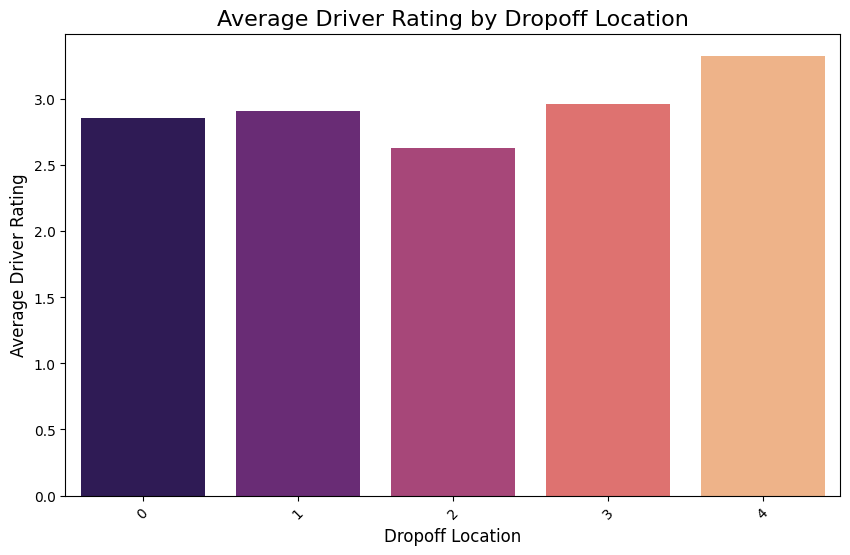

In [ ]:

# Driver Rating by Dropoff Location
plt.figure(figsize=(10, 6))
avg_rating_by_dropoff = cab_ride_df.groupby('Dropoff_Location')['Driver_Rating'].mean().reset_index()
sns.barplot(x='Dropoff_Location', y='Driver_Rating', data=avg_rating_by_dropoff, palette="magma")
plt.title("Average Driver Rating by Dropoff Location", fontsize=16)
plt.xlabel("Dropoff Location", fontsize=12)
plt.ylabel("Average Driver Rating", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Assuming cab_ride_df is already defined, make sure you have your data in the DataFrame.
# Example of cab_ride_df DataFrame (if needed for reference)
cab_ride_df = pd.DataFrame({
    'Pickup_Location': ['New York', 'Los Angeles', 'Mumbai'],
    'Dropoff_Location': ['London', 'Paris', 'Berlin']
})

# Dictionary mapping cities to latitude and longitude
city_coordinates = {
    "New York": {"lat": 40.7128, "lon": -74.0060},
    "Los Angeles": {"lat": 34.0522, "lon": -118.2437},
    "Mumbai": {"lat": 19.0760, "lon": 72.8777},
    "London": {"lat": 51.5074, "lon": -0.1278},
    "Berlin": {"lat": 52.5200, "lon": 13.4050},
    "San Francisco": {"lat": 37.7749, "lon": -122.4194},
    "Chicago": {"lat": 41.8781, "lon": -87.6298},
    "Delhi": {"lat": 28.6139, "lon": 77.2090},
    "Paris": {"lat": 48.8566, "lon": 2.3522},
    "Amsterdam": {"lat": 52.3676, "lon": 4.9041}
}

# Add latitude and longitude for pickup and dropoff locations
cab_ride_df['Pickup_Lat'] = cab_ride_df['Pickup_Location'].map(lambda loc: city_coordinates[loc]['lat'])
cab_ride_df['Pickup_Lon'] = cab_ride_df['Pickup_Location'].map(lambda loc: city_coordinates[loc]['lon'])
cab_ride_df['Dropoff_Lat'] = cab_ride_df['Dropoff_Location'].map(lambda loc: city_coordinates[loc]['lat'])
cab_ride_df['Dropoff_Lon'] = cab_ride_df['Dropoff_Location'].map(lambda loc: city_coordinates[loc]['lon'])

# Create a DataFrame for plotting both pickup and dropoff locations
pickup_df = cab_ride_df[['Pickup_Lat', 'Pickup_Lon', 'Pickup_Location']].rename(columns={'Pickup_Lat': 'lat', 'Pickup_Lon': 'lon', 'Pickup_Location': 'Location'})
pickup_df['Type'] = 'Pickup'  # Mark as Pickup

dropoff_df = cab_ride_df[['Dropoff_Lat', 'Dropoff_Lon', 'Dropoff_Location']].rename(columns={'Dropoff_Lat': 'lat', 'Dropoff_Lon': 'lon', 'Dropoff_Location': 'Location'})
dropoff_df['Type'] = 'Dropoff'  # Mark as Dropoff

# Combine both DataFrames
combined_df = pd.concat([pickup_df, dropoff_df], ignore_index=True)

# Plot both pickup and dropoff locations on a map using plotly.express
fig = px.scatter_geo(
    combined_df,
    lat="lat",
    lon="lon",
    hover_name="Location",
    color="Type",
    title="Cab Ride Pickup and Drop Locations",
    color_discrete_map={'Pickup': 'blue', 'Dropoff': 'red'},  # Different colors for pickup and dropoff
    projection="natural earth"
)

# Show the map
fig.show()


In [ ]:
# Creating a bar chart showing total fare amount by User_ID
bar_chart = cab_ride_df.groupby('User_ID')['Fare_Amount'].sum().reset_index()

# Create a bar chart
fig = px.bar(bar_chart, x='User_ID', y='Fare_Amount',
             title='Total Fare Amount by User ID',
             hover_data=['User_ID', 'Fare_Amount'],  # Show information on hover
             labels={'Fare_Amount': 'Total Fare Amount ($)', 'User_ID': 'User ID'})

# Show the plot
fig.show()


In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Helper function to generate random timestamps
def random_date(start, end):
    return start + timedelta(seconds=random.randint(0, int((end - start).total_seconds())))

# Generate the dataset
start_date = datetime(2024, 9, 1)
end_date = datetime(2024, 9, 26)
data = {
    "User_ID": [f"U{str(i).zfill(4)}" for i in range(1, 101)],
    "Session_ID": [f"S{random.randint(10000, 99999)}" for _ in range(100)],
    "Device_ID": [f"D{random.randint(1000, 9999)}" for _ in range(100)],
    "App_Version": [random.choice(["1.0", "1.1", "1.2", "2.0"]) for _ in range(100)],
    "Event_Name": [random.choice(["Booking", "Cancellation", "Ride Start", "Ride End", "Payment"]) for _ in range(100)],
    "Event_Time": [random_date(start_date, end_date) for _ in range(100)],
    "Pickup_Location": [random.choice(["New York", "Los Angeles", "Mumbai", "London", "Berlin"]) for _ in range(100)],
    "Dropoff_Location": [random.choice(["San Francisco", "Chicago", "Delhi", "Paris", "Amsterdam"]) for _ in range(100)],
    "Ride_Distance_km": [round(random.uniform(5.0, 50.0), 2) for _ in range(100)],
    "Driver_Rating": [round(random.uniform(1.0, 5.0), 1) for _ in range(100)],
    "Fare_Amount": [round(random.uniform(10.0, 100.0), 2) for _ in range(100)],
}
cab_ride_df = pd.DataFrame(data)

# Data preprocessing
le = LabelEncoder()
cab_ride_df['Pickup_Location'] = le.fit_transform(cab_ride_df['Pickup_Location'])
cab_ride_df['Dropoff_Location'] = le.fit_transform(cab_ride_df['Dropoff_Location'])
X = cab_ride_df[['Pickup_Location', 'Ride_Distance_km', 'Driver_Rating', 'Fare_Amount']]
y = cab_ride_df['Dropoff_Location']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model building
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))


Accuracy: 0.25
              precision    recall  f1-score   support

           0       0.30      0.43      0.35         7
           1       0.00      0.00      0.00         2
           2       0.20      0.25      0.22         4
           3       0.25      0.17      0.20         6
           4       0.00      0.00      0.00         1

    accuracy                           0.25        20
   macro avg       0.15      0.17      0.16        20
weighted avg       0.22      0.25      0.23        20



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



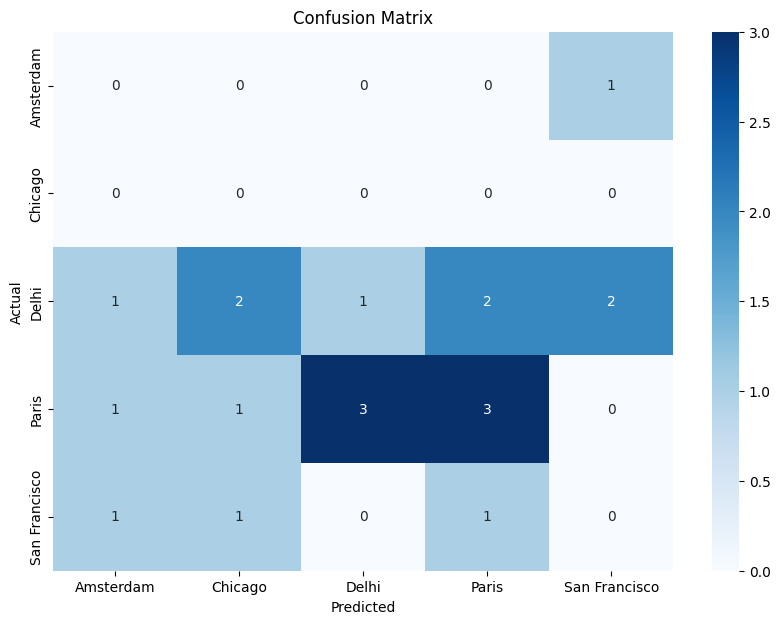

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression

# Train a logistic regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate logistic regression model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {accuracy_lr:.2f}')


Logistic Regression Accuracy: 0.05


<ipython-input-85-adbbbccf8d21>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




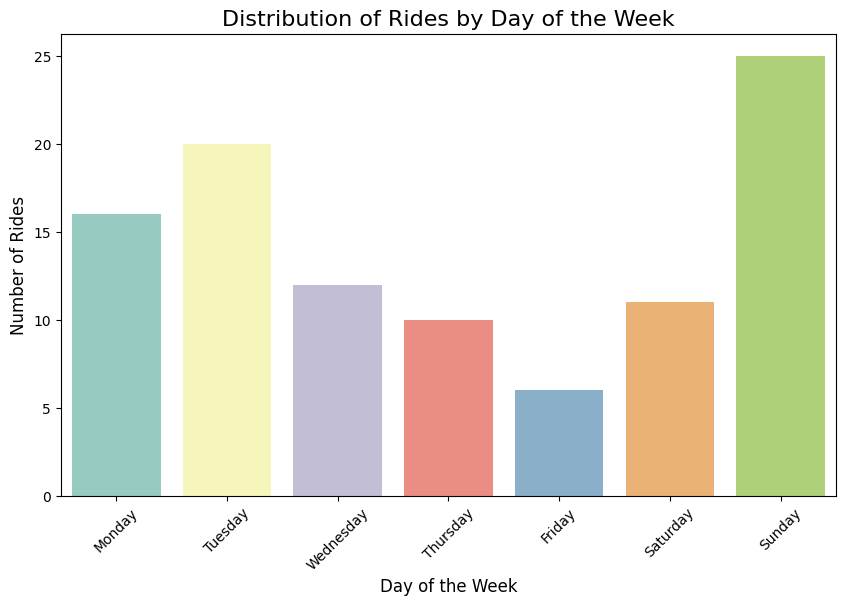

In [ ]:
# Distribution of Rides by Day of the Week
cab_ride_df['Day_of_Week'] = cab_ride_df['Event_Time'].dt.day_name()  # Extract day of the week

plt.figure(figsize=(10, 6))
sns.countplot(x='Day_of_Week', data=cab_ride_df, order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], palette="Set3")
plt.title("Distribution of Rides by Day of the Week", fontsize=16)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Rides", fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-87-2c582f629675>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




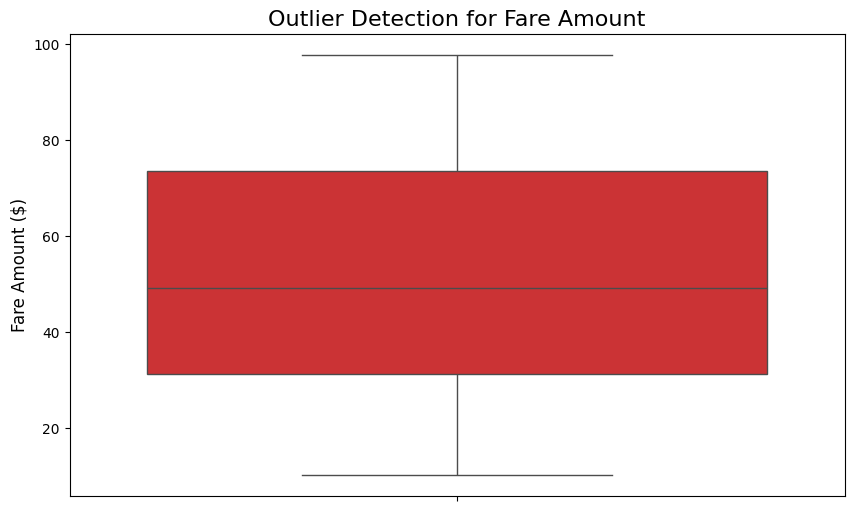

In [ ]:
# Outlier Detection for Fare Amount
plt.figure(figsize=(10, 6))
sns.boxplot(y='Fare_Amount', data=cab_ride_df, palette="Set1")
plt.title("Outlier Detection for Fare Amount", fontsize=16)
plt.ylabel("Fare Amount ($)", fontsize=12)
plt.show()


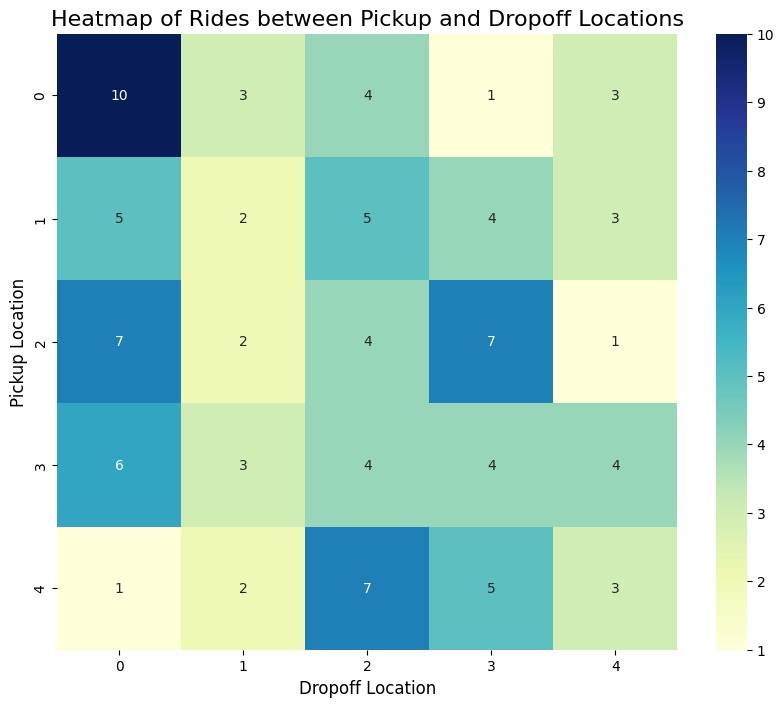

In [ ]:
# Ride Popularity by Pickup and Dropoff Location (Heatmap)
pickup_dropoff_counts = pd.crosstab(cab_ride_df['Pickup_Location'], cab_ride_df['Dropoff_Location'])

plt.figure(figsize=(10, 8))
sns.heatmap(pickup_dropoff_counts, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Heatmap of Rides between Pickup and Dropoff Locations", fontsize=16)
plt.xlabel("Dropoff Location", fontsize=12)
plt.ylabel("Pickup Location", fontsize=12)
plt.show()

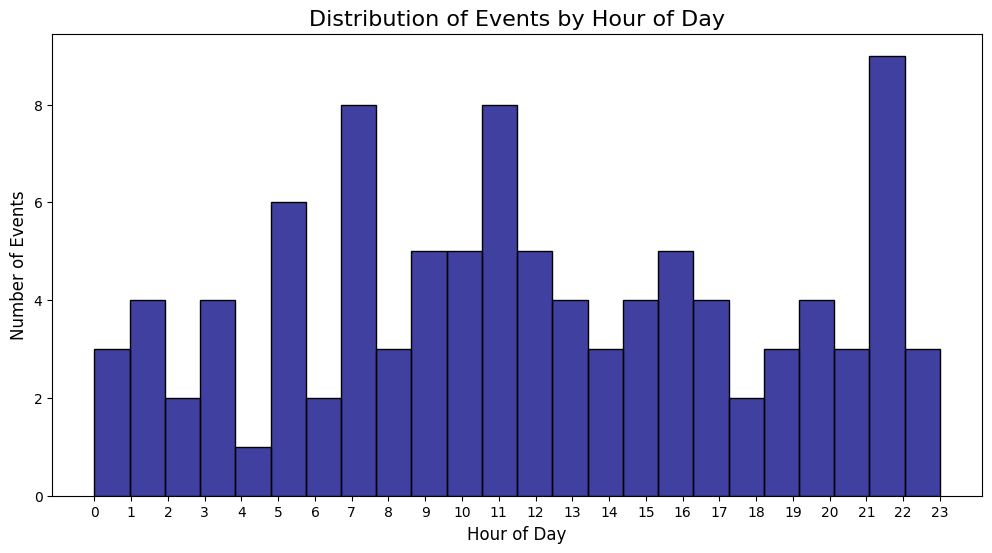

In [ ]:
# Event Time Distribution (Hourly Analysis)
cab_ride_df['Hour'] = cab_ride_df['Event_Time'].dt.hour  # Extract hour from event time

plt.figure(figsize=(12, 6))
sns.histplot(cab_ride_df['Hour'], bins=24, kde=False, color="navy")
plt.title("Distribution of Events by Hour of Day", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Number of Events", fontsize=12)
plt.xticks(range(0, 24))
plt.show()

<ipython-input-90-3584d0304e2e>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




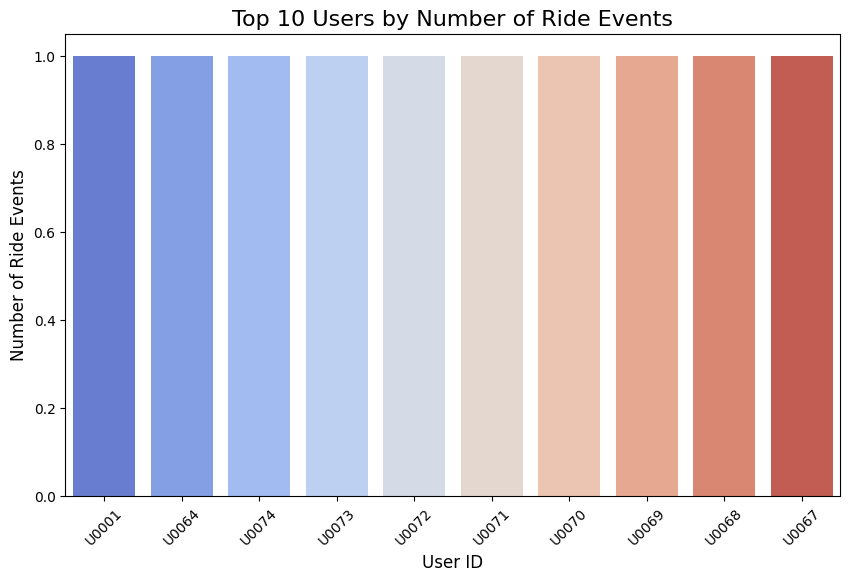

In [ ]:
#  Distribution of Ride Events by User
plt.figure(figsize=(10, 6))
top_users = cab_ride_df['User_ID'].value_counts().nlargest(10).index
sns.countplot(x='User_ID', data=cab_ride_df[cab_ride_df['User_ID'].isin(top_users)], order=top_users, palette="coolwarm")
plt.title("Top 10 Users by Number of Ride Events", fontsize=16)
plt.xlabel("User ID", fontsize=12)
plt.ylabel("Number of Ride Events", fontsize=12)
plt.xticks(rotation=45)
plt.show()


<ipython-input-91-da00cdabc204>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




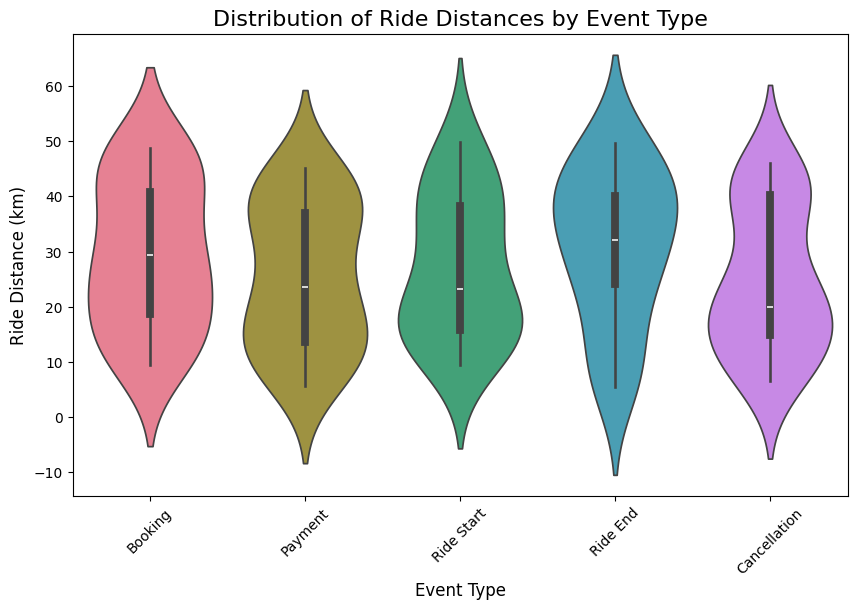

In [ ]:
#  Distribution of Ride Distances by Event Type
plt.figure(figsize=(10, 6))
sns.violinplot(x='Event_Name', y='Ride_Distance_km', data=cab_ride_df, palette="husl", inner="box")
plt.title("Distribution of Ride Distances by Event Type", fontsize=16)
plt.xlabel("Event Type", fontsize=12)
plt.ylabel("Ride Distance (km)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

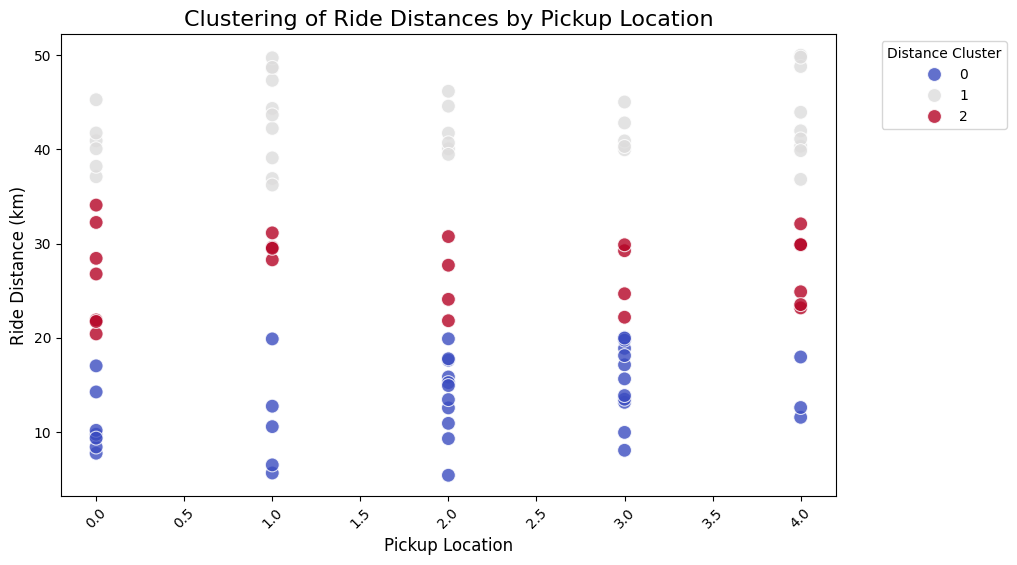

In [ ]:
#  Clustering of Pickup Locations Based on Ride Distances (KMeans)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# Scale ride distances
scaler = StandardScaler()
cab_ride_df['Scaled_Ride_Distance'] = scaler.fit_transform(cab_ride_df[['Ride_Distance_km']])

# Perform KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cab_ride_df['Distance_Cluster'] = kmeans.fit_predict(cab_ride_df[['Scaled_Ride_Distance']])

# Plot Clusters of Ride Distances by Pickup Location
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Pickup_Location', y='Ride_Distance_km', hue='Distance_Cluster', data=cab_ride_df, palette='coolwarm', s=100, alpha=0.8)
plt.title("Clustering of Ride Distances by Pickup Location", fontsize=16)
plt.xlabel("Pickup Location", fontsize=12)
plt.ylabel("Ride Distance (km)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Distance Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<ipython-input-94-527abc9ba80d>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




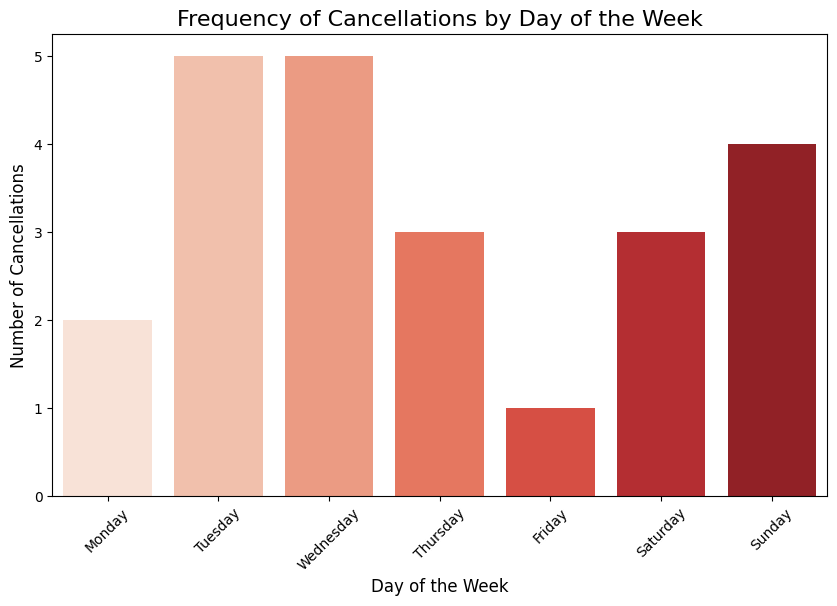

In [ ]:
# Frequency of Cancellations by Day of the Week
plt.figure(figsize=(10, 6))
sns.countplot(x='Day_of_Week', data=cab_ride_df[cab_ride_df['Event_Name'] == "Cancellation"], order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], palette="Reds")
plt.title("Frequency of Cancellations by Day of the Week", fontsize=16)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Cancellations", fontsize=12)
plt.xticks(rotation=45)
plt.show()